In [ ]:
# import os
# import glob

# # ================= 1. 定义路径 =================
# # 脚本路径
# script_path = "/data/work/02.result/colocalization_20251226/py/colocalization.py"

# # 输入数据路径 (h5ad)
# data_dir = "/data/input/Files/02.ST/01.data"

# # 元数据路径 (csv)
# meta_dir = "/data/work/02.result/colocalization_20251226/sp_meta"

# # 输出结果保存路径 (会自动创建)
# out_dir = "/data/work/02.result/colocalization_20251226/py"
# os.makedirs(out_dir, exist_ok=True)

# # ================= 2. 获取文件列表并匹配 =================
# # 获取所有的 meta csv 文件
# meta_files = glob.glob(os.path.join(meta_dir, "*.csv"))

# print(f"找到 {len(meta_files)} 个元数据文件，准备开始处理...\n")

# for meta_file in meta_files:
#     # --- 2.1 提取 Sample ID ---
#     # 文件名示例: M1_D14-anno_meta.csv -> ID: M1_D14
#     meta_basename = os.path.basename(meta_file)
#     sample_id = meta_basename.split('-')[0] 
    
#     # --- 2.2 寻找对应的 h5ad 文件 ---
#     # 在 data 目录下搜索包含 sample_id 且以 .h5ad 结尾的文件
#     # 注意：你的 data 目录下有 .h5ad 和 .rds，我们要精准匹配 .h5ad
#     search_pattern = os.path.join(data_dir, f"*{sample_id}*.h5ad")
#     found_h5ad = glob.glob(search_pattern)
    
#     if len(found_h5ad) == 0:
#         print(f"⚠️  跳过: 未找到 ID 为 {sample_id} 的 h5ad 文件")
#         continue
    
#     # 取第一个匹配到的文件 (通常只会有一个)
#     input_h5ad = found_h5ad[0]
    
#     # --- 2.3 定义输出文件名 ---
#     save_filename = os.path.join(out_dir, f"{sample_id}_enrichment.csv")
    
#     # ================= 3. 构建并执行命令 =================
    
#     print(f"正在处理: {sample_id}")
#     print(f"  Input: {os.path.basename(input_h5ad)}")
#     print(f"  Meta:  {os.path.basename(meta_file)}")
    
#     # 使用 Jupyter 的魔法命令变量扩展功能
#     # 在 Jupyter 中，!python {var} 可以直接读取 python 变量
#     !python {script_path} -I {input_h5ad} -M {meta_file} -F {save_filename} -K 20
    
#     print("-" * 50)

# print("✅ 所有任务处理完成！")

In [22]:
meta

,From,To,Counts,Log2FC,Pvalue,Percentage
0,AntiInfMacr,AntiInfMacr,44,4.862418,0.000000,0.019634
1,AntiInfMacr,B,9,1.041389,0.034450,0.004016
2,AntiInfMacr,Bas-I,32,-0.772030,0.999683,0.014279
3,AntiInfMacr,Bas-II,10,-1.276724,0.999654,0.004462
4,AntiInfMacr,Bas-inflamed,15,0.056438,0.474623,0.006693
...,...,...,...,...,...,...
1439,trMacr,myoFB,1216,-4.025244,1.000000,0.007159
1440,trMacr,ncMono,1185,1.581128,0.000000,0.006976
1441,trMacr,papiFB,1442,-0.627878,1.000000,0.008489
1442,trMacr,retiFB,24674,-0.280860,1.000000,0.145263


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# 假设你的数据变量叫 df (即你代码里的 meta)
df = pd.read_csv('M1_D14_enrichment.csv', index_col=0)

# 1. 处理无穷大值：将 -inf 替换为一个具体的最小值 (比如数据中最小的有限值的1.1倍)
min_val = df.loc[df['Log2FC'] != -np.inf, 'Log2FC'].min()
df['Log2FC'] = df['Log2FC'].replace(-np.inf, min_val * 1.1)

# 同理处理 inf (虽然一般不会出现正无穷，为了保险)
max_val = df.loc[df['Log2FC'] != np.inf, 'Log2FC'].max()
df['Log2FC'] = df['Log2FC'].replace(np.inf, max_val * 1.1)

# 2. 计算 -log10(Pvalue) 用于可视化显著性
# 加上一个极小值 1e-300 防止 log10(0) 报错
df['neg_log_p'] = -np.log10(df['Pvalue'] + 1e-300) # neg_log_p 是对 P值 进行负对数转换后的结果。 转换后，数值越大，代表越显著（P值越小）

# 3. 截断极值 (可选)：为了防止颜色条被个别极端值拉偏，通常限制 Log2FC 范围
# 例如限制在 -3 到 3 之间
df['Log2FC_clipped'] = df['Log2FC'].clip(-3, 3)

print("数据清洗完成")

数据清洗完成


In [20]:
df

# From (中心细胞类型)： 分析的参照点。
# To (邻居细胞类型)： 在中心细胞（From）周围 K 个邻居范围内出现的细胞类型。
# Counts (连接计数)： 在整个空间切片中，所有 From 类型的细胞与 To 类型的细胞之间实际发生的空间邻接次数（边数）。这个数值越大，说明这两种细胞在物理空间上的接触越频繁。
# Percentage (邻居占比)： 公式：Counts/From类型的总邻居数。 它表示：在 From 类型细胞的所有邻居中，To 类型细胞所占的比例。这可以让你直观感受到某种细胞被另一种细胞“包围”的程度。

# Log2FC (Log2 Fold Change，富集倍数)： 这是衡量空间偏好性的核心指标。

# neg_log_p： 对 P 值进行的负对数转换，数值越大，代表越显著。

# Log2FC_clipped (截断后的 Log2FC)： 这是为了绘图美观做的处理。
# 目的：防止个别极端的 Log2FC（比如 50 或 -50）拉偏颜色条的比例。
# 处理：通常将值限制在 [−3,3]。这意味着即使某个富集倍数是 10，在热图上也显示为最深的红色，从而保证其他 Log2FC 为 1 或 2 的显著点也能呈现出颜色差异。

,From,To,Counts,Log2FC,Pvalue,Percentage,neg_log_p,Log2FC_clipped
0,AntiInfMacr,AntiInfMacr,44,4.862418,0.000000,0.019634,300.000000,3.000000
1,AntiInfMacr,B,9,1.041389,0.034450,0.004016,1.462817,1.041389
2,AntiInfMacr,Bas-I,32,-0.772030,0.999683,0.014279,0.000138,-0.772030
3,AntiInfMacr,Bas-II,10,-1.276724,0.999654,0.004462,0.000150,-1.276724
4,AntiInfMacr,Bas-inflamed,15,0.056438,0.474623,0.006693,0.323651,0.056438
...,...,...,...,...,...,...,...,...
1439,trMacr,myoFB,1216,-4.025244,1.000000,0.007159,-0.000000,-3.000000
1440,trMacr,ncMono,1185,1.581128,0.000000,0.006976,300.000000,1.581128
1441,trMacr,papiFB,1442,-0.627878,1.000000,0.008489,-0.000000,-0.627878
1442,trMacr,retiFB,24674,-0.280860,1.000000,0.145263,-0.000000,-0.280860


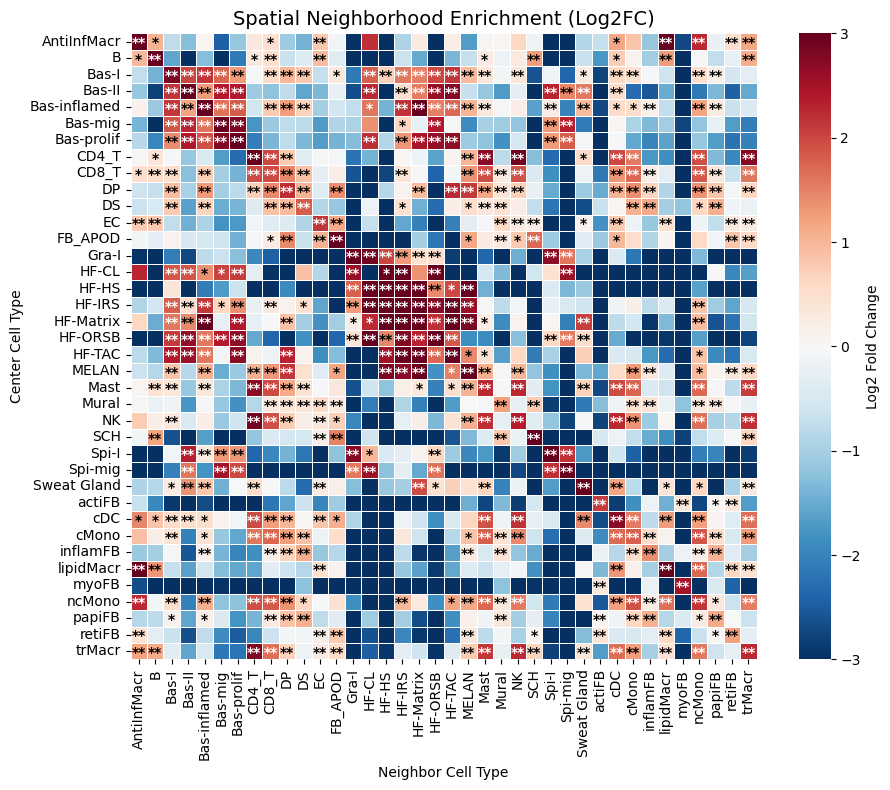

In [17]:
def plot_enrichment_heatmap(data, value_col='Log2FC_clipped', p_col='Pvalue'):
    # 1. 转换数据格式：长表变宽表
    matrix_fc = data.pivot(index='From', columns='To', values=value_col)
    matrix_p = data.pivot(index='From', columns='To', values=p_col)
    
    # 2. 填充缺失值为0 (自对角线或其他无数据区域)
    matrix_fc = matrix_fc.fillna(0)
    matrix_p = matrix_p.fillna(1)

    # 3. 设置画布
    plt.figure(figsize=(10, 8))
    
    # 4. 绘制热图
    # cmap='RdBu_r' : 红色代表正值(吸引)，蓝色代表负值(排斥)，白色为0
    # center=0 : 确保白色对齐0
    ax = sns.heatmap(matrix_fc, cmap='RdBu_r', center=0, 
                     annot=False, square=True, linewidths=0.5,
                     cbar_kws={'label': 'Log2 Fold Change'})
    
    # 5. 添加显著性标记
    # 遍历矩阵，如果 P < 0.05 (或者 0.01)，添加星号
    for y in range(matrix_p.shape[0]):
        for x in range(matrix_p.shape[1]):
            p_val = matrix_p.iloc[y, x]
            fc_val = matrix_fc.iloc[y, x]
            # 只有当显著 且 Log2FC 不为0时才标记
            if p_val < 0.05:
                # 根据背景色深浅调整星号颜色
                text_color = 'white' if abs(fc_val) > 1.5 else 'black'
                sig_symbol = '**' if p_val < 0.001 else '*'
                ax.text(x + 0.5, y + 0.6, sig_symbol, 
                        horizontalalignment='center', verticalalignment='center',
                        color=text_color, fontsize=10, weight='bold')

    plt.title('Spatial Neighborhood Enrichment (Log2FC)', fontsize=14)
    plt.xlabel('Neighbor Cell Type')
    plt.ylabel('Center Cell Type')
    plt.tight_layout()
    plt.show()

# 运行
plot_enrichment_heatmap(df)

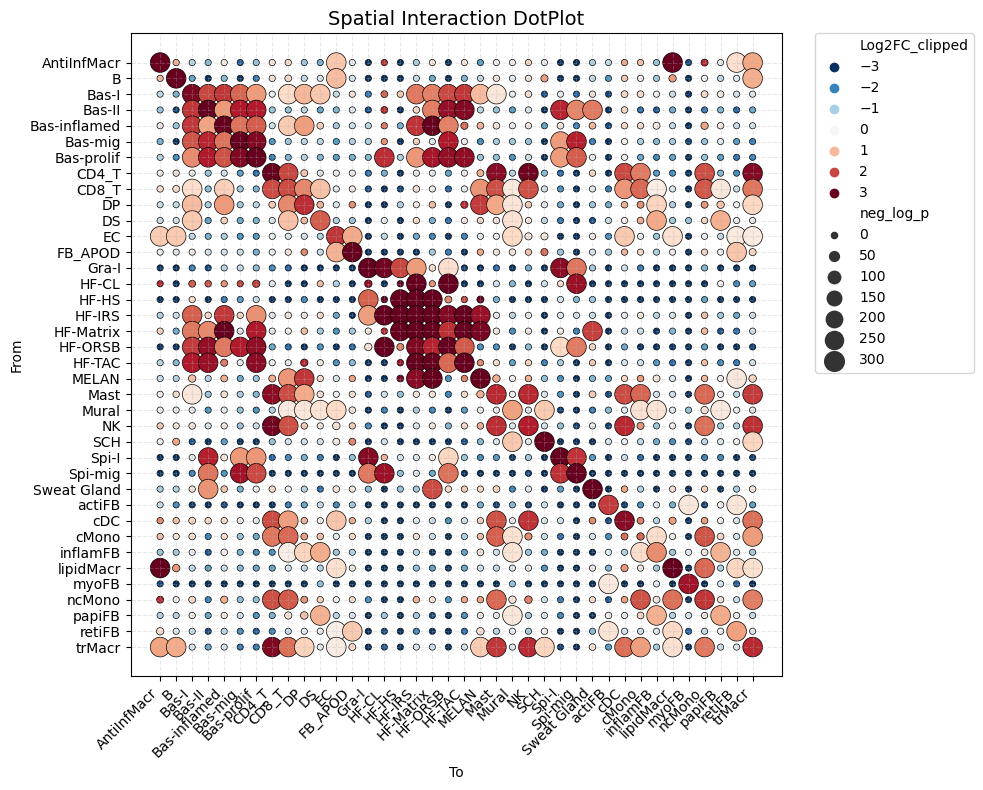

In [18]:
def plot_enrichment_dotplot(data):
    # 过滤：只展示 P < 0.05 的显著结果 (如果不显著的也要看，可以注释掉这行)
    # data_plot = data[data['Pvalue'] < 0.05].copy() 
    data_plot = data.copy()
    
    # 设置画布
    plt.figure(figsize=(10, 8))
    
    # 绘制散点
    # hue (颜色): Log2FC
    # size (大小): Counts 或 Percentage 或 -log10(P)
    scatter = sns.scatterplot(data=data_plot, 
                              x='To', y='From', 
                              hue='Log2FC_clipped', size='neg_log_p',
                              palette='RdBu_r', sizes=(20, 200), 
                              edgecolor='black', linewidth=0.5)
    
    # 调整图例位置
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    
    # 调整轴标签旋转
    plt.xticks(rotation=45, ha='right')
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.title('Spatial Interaction DotPlot', fontsize=14)
    plt.tight_layout()
    plt.show()

# 运行
plot_enrichment_dotplot(df)

## 循环

In [21]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ================= 配置部分 =================
input_dir = "./"  # 输入文件所在目录 (当前目录)
output_dir = "./plot"  # 输出图片目录
os.makedirs(output_dir, exist_ok=True) # 自动创建 plot 文件夹

# 设置绘图风格
sns.set(style="whitegrid", font_scale=1.0)
plt.rcParams['pdf.fonttype'] = 42 # 保证导出PDF文字可编辑
plt.rcParams['ps.fonttype'] = 42

# ================= 核心绘图函数 =================

def preprocess_data(df):
    """数据预处理：处理无穷大，计算 -log10P，截断极端值"""
    data = df.copy()
    
    # 1. 处理 Log2FC 的无穷大值
    # 将 -inf 替换为 (最小值 * 1.1) 或 -5 (保底)
    # 将 inf 替换为 (最大值 * 1.1) 或 5 (保底)
    finite_vals = data.loc[np.isfinite(data['Log2FC']), 'Log2FC']
    
    if len(finite_vals) > 0:
        min_val, max_val = finite_vals.min(), finite_vals.max()
        # 避免全是一样的值导致错误
        if min_val == max_val: 
            min_val -= 1
            max_val += 1
    else:
        min_val, max_val = -3, 3 # 默认回退值

    # 替换 -inf 和 inf
    data['Log2FC'] = data['Log2FC'].replace(-np.inf, min_val * 1.1)
    data['Log2FC'] = data['Log2FC'].replace(np.inf, max_val * 1.1)

    # 2. 截断 (Clipping)：为了视觉效果，限制 Log2FC 在 [-3, 3] 之间
    # 这样可以防止个别极端值导致整个热图颜色变淡
    data['Log2FC_Plot'] = data['Log2FC'].clip(-3, 3)

    # 3. 计算 -log10(Pvalue)
    # 加一个极小值防止报错
    data['neg_log_p'] = -np.log10(data['Pvalue'] + 1e-300)
    
    return data

def plot_heatmap(data, sample_id, out_path):
    """绘制带有显著性标记的热图"""
    # 转换矩阵
    matrix_fc = data.pivot(index='From', columns='To', values='Log2FC_Plot').fillna(0)
    matrix_p = data.pivot(index='From', columns='To', values='Pvalue').fillna(1)
    
    plt.figure(figsize=(10, 8))
    
    # 绘制热图
    ax = sns.heatmap(matrix_fc, cmap='RdBu_r', center=0, 
                     annot=False, square=True, linewidths=0.5, linecolor='grey',
                     cbar_kws={'label': 'Log2 Fold Change (Clipped -3 to 3)'})
    
    # 添加显著性标记
    for y in range(matrix_p.shape[0]):
        for x in range(matrix_p.shape[1]):
            p_val = matrix_p.iloc[y, x]
            fc_val = matrix_fc.iloc[y, x]
            
            if p_val < 0.05:
                # 决定星号颜色 (深背景用白字，浅背景用黑字)
                text_color = 'white' if abs(fc_val) > 1.5 else 'black'
                sig_symbol = '**' if p_val < 0.001 else '*'
                
                ax.text(x + 0.5, y + 0.6, sig_symbol, 
                        ha='center', va='center', color=text_color, 
                        fontsize=12, weight='bold')

    plt.title(f'Spatial Enrichment: {sample_id}', fontsize=14)
    plt.xlabel('Neighbor Cell Type')
    plt.ylabel('Center Cell Type')
    plt.tight_layout()
    
    # 保存
    save_file = os.path.join(out_path, f"{sample_id}_Heatmap.pdf")
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    plt.close() # 关闭画布释放内存

def plot_dotplot(data, sample_id, out_path):
    """绘制气泡图"""
    plt.figure(figsize=(11, 8))
    
    # 绘制散点
    # hue: 颜色映射 Log2FC
    # size: 大小映射显著性
    sns.scatterplot(data=data, x='To', y='From', 
                    hue='Log2FC_Plot', size='neg_log_p',
                    palette='RdBu_r', sizes=(10, 300), 
                    edgecolor='black', linewidth=0.5,
                    hue_norm=(-3, 3)) # 固定颜色范围确保所有图一致
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Stats')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.title(f'Spatial Interaction: {sample_id}', fontsize=14)
    plt.xlabel('Neighbor Cell Type')
    plt.ylabel('Center Cell Type')
    plt.tight_layout()
    
    # 保存
    save_file = os.path.join(out_path, f"{sample_id}_Dotplot.pdf")
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    plt.close()

# ================= 主循环 =================

# 匹配所有 csv 文件
files = glob.glob(os.path.join(input_dir, "*_enrichment.csv"))
print(f"找到 {len(files)} 个结果文件，开始绘图...\n")

for f in files:
    # 提取 Sample ID (例如 M1_D14)
    # 文件名: /path/to/M1_D14_enrichment.csv -> M1_D14
    basename = os.path.basename(f)
    sample_id = basename.replace('_enrichment.csv', '')
    
    print(f"正在处理: {sample_id}")
    
    try:
        # 读取
        df = pd.read_csv(f, index_col=0)
        
        if df.empty:
            print(f"  ⚠️ 跳过: {sample_id} 文件为空")
            continue
            
        # 预处理
        df_clean = preprocess_data(df)
        
        # 绘图 1: 热图
        plot_heatmap(df_clean, sample_id, output_dir)
        
        # 绘图 2: 气泡图
        plot_dotplot(df_clean, sample_id, output_dir)
        
    except Exception as e:
        print(f"  ❌ 错误: {sample_id} 处理失败 - {str(e)}")

print("\n✅ 所有绘图完成！结果已保存在 ./plot 文件夹中。")

找到 12 个结果文件，开始绘图...

正在处理: M2_D21
正在处理: M1_D21
正在处理: M4_D7
正在处理: M4_D21
正在处理: M4_D3
正在处理: M1_D7
正在处理: M1_D14
正在处理: M4_D14
正在处理: M2_D3
正在处理: M2_D14
正在处理: M1_D3
正在处理: M2_D7

✅ 所有绘图完成！结果已保存在 ./plot 文件夹中。
